In [61]:
import io
import os
import urllib
import zipfile
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import xlabel
from networkx.algorithms.bipartite.basic import color

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler


In [62]:
train_signals = os.listdir('/home/zhouliang/PycharmProjects/NAB_art/NAB/artificialWithAnomaly/artificialWithAnomaly')

In [63]:
df = pd.read_csv('/home/zhouliang/PycharmProjects/NAB_art/NAB/realAWSCloudwatch/realAWSCloudwatch/ec2_cpu_utilization_5f5533.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  4032 non-null   object 
 1   value      4032 non-null   float64
dtypes: float64(1), object(1)
memory usage: 63.1+ KB
None


In [64]:
df.head(10)

,timestamp,value
0,2014-02-14 14:27:00,51.846
1,2014-02-14 14:32:00,44.508
2,2014-02-14 14:37:00,41.244
3,2014-02-14 14:42:00,48.568
4,2014-02-14 14:47:00,46.714
5,2014-02-14 14:52:00,44.986
6,2014-02-14 14:57:00,49.108
7,2014-02-14 15:02:00,40.470
8,2014-02-14 15:07:00,53.404
9,2014-02-14 15:12:00,45.400


In [65]:
df["timestamp"] = pd.to_datetime(df.timestamp)

df['timestamp'] = (df['timestamp'] - pd.Timestamp('1970-01-01')) // pd.Timedelta('1s')
df.head()

,timestamp,value
0,1392388020,51.846
1,1392388320,44.508
2,1392388620,41.244
3,1392388920,48.568
4,1392389220,46.714


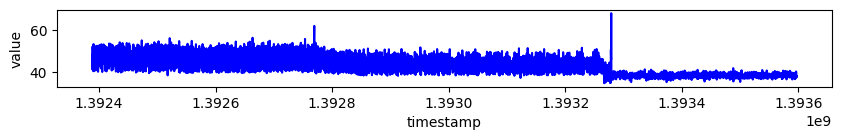

In [66]:
plt.figure(figsize = (10,1))
plt.plot(df.timestamp,df.value,color= 'blue')
plt.ylabel('value')
plt.xlabel('timestamp')
plt.show()

In [67]:
from orion.data import load_signal, load_anomalies
known_anomalies = load_anomalies('ec2_cpu_utilization_5f5533')
known_anomalies

,start,end
0,1392735720,1392795720
1,1393233420,1393293420


In [68]:
def plot_func_with_anomaly(data, anomalies, test = False, predicted_anomalies = None, save_path = None):
    plt.figure(figsize= (20, 4))
    plt.plot(df['timestamp'], data['value'], label= "Time series Data")
    for i, row in  anomalies.iterrows():
        plt.axvspan(row['start'], row['end'], color = 'green', alpha = 0.3, label = 'Anomalous part')

    if(test==True):
        for i, row in predicted_anomalies.iterrows():
            plt.axvspan(row['start'], row['end'], color='red', alpha=0.3, label='predicted Anomalous Part')

    # Add legend and labels
    plt.legend()
    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.title('Time Series Plot with Anomalous Parts')
    if save_path:
        plt.savefig(save_path, format=save_path.split('.')[-1], bbox_inches='tight')
    # Show plot
    plt.show()


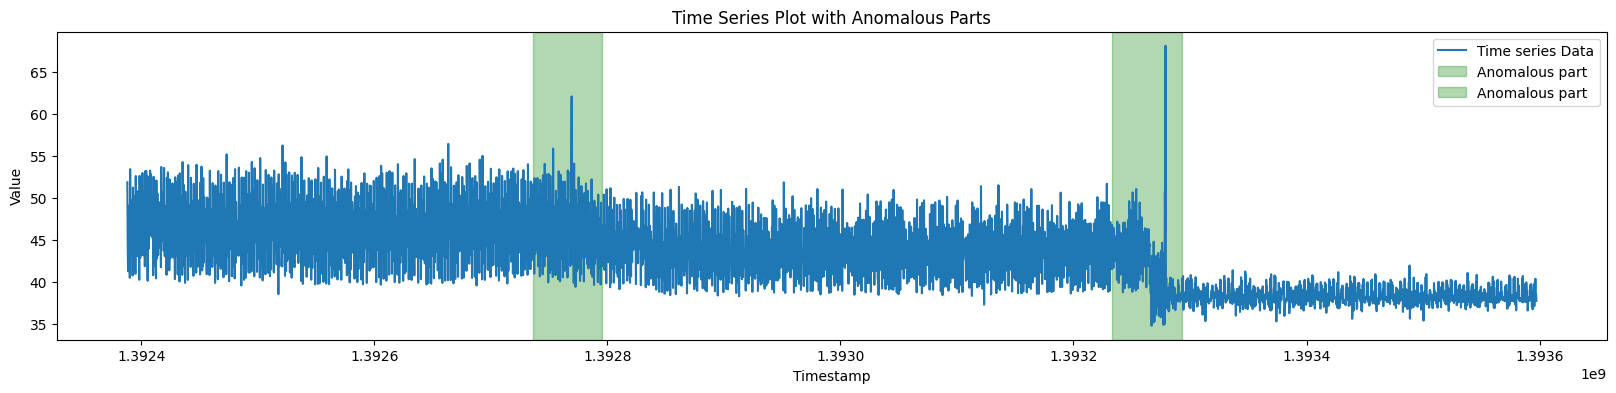

In [69]:
plot_func_with_anomaly(df, known_anomalies, save_path= 'cpu_5f.svg')

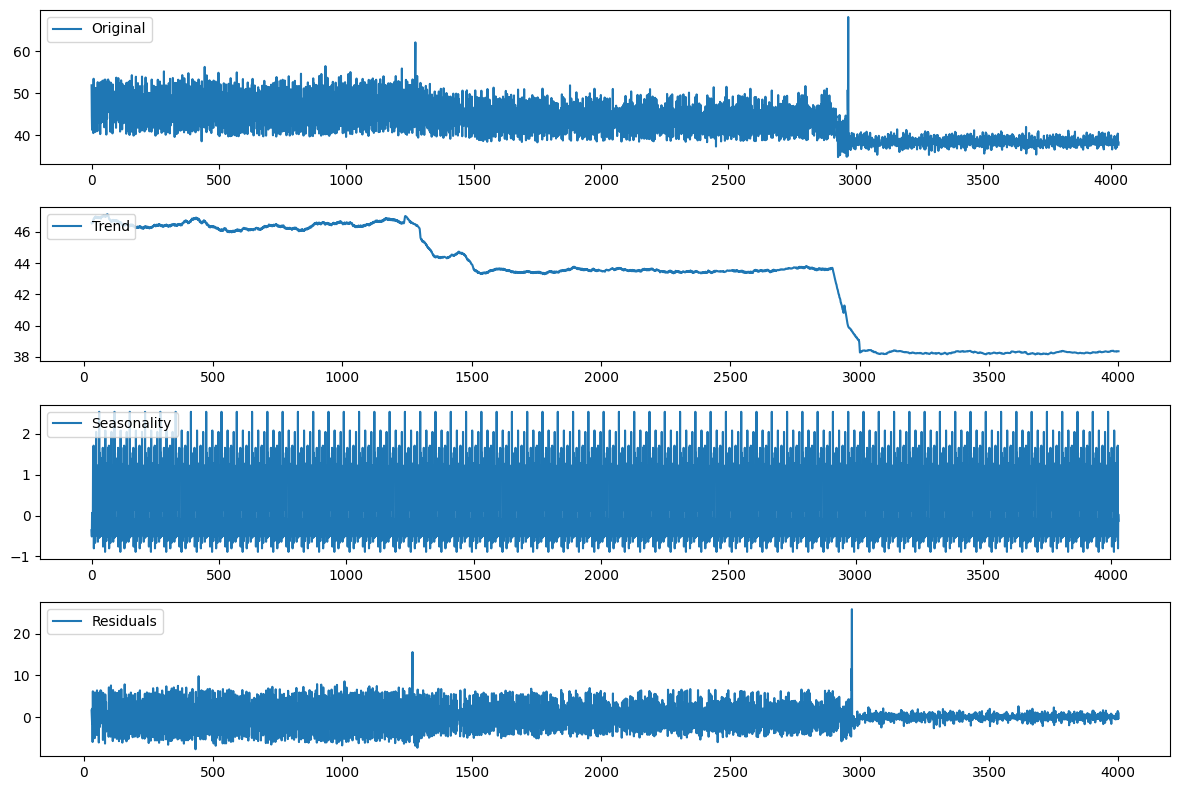

In [70]:
from statsmodels.tsa.seasonal import seasonal_decompose
#Todo:
decomposition = seasonal_decompose(df['value'], model='additive', period=60)

# Extract the components
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot the original series and the decomposition components
plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df['value'], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('cpu_5f_trend.svg', format='svg', bbox_inches='tight')
plt.show()


In [71]:
df_noise=pd.DataFrame({'timestamp':df['timestamp'],'value':residual})
df_noise.head()

,timestamp,value
0,1392388020,NaN
1,1392388320,NaN
2,1392388620,NaN
3,1392388920,NaN
4,1392389220,NaN


In [72]:
trend=np.array(residual)
trend.shape
trend2=trend.reshape(-1,1)
trend2.shape

(4032, 1)

In [73]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
imp = SimpleImputer()

trend_no_null= imp.fit_transform(trend2)
trend2_flatten = trend2.flatten()

trend_no_null=trend_no_null.flatten()
print(trend_no_null.shape)
df_trend_no_null=pd.DataFrame({'timestamp':df['timestamp'],'value':trend_no_null})
df_trend_no_null.head()

(4032,)


,timestamp,value
0,1392388020,0.000551
1,1392388320,0.000551
2,1392388620,0.000551
3,1392388920,0.000551
4,1392389220,0.000551


In [74]:
#data = trend_no_null.reshape(-1, 1)
#print(data.shape)

In [75]:
import numpy as np
import pandas as pd
from filterpy.kalman import KalmanFilter

def kf_rts_fill(
        ts_values: np.ndarray,
        timestamps: np.ndarray,
        freq: str = "1min",     # 'min' 替代 'T'
        Q: float = 1e-5,
        R: float = 1e-2,
        init_var: float = 10.0) -> pd.DataFrame:
    """
    KF + RTS smoothing with automatic resampling, gap‑filling and denoising.
    """

    # 1⃣ 组装等间隔时间网格
    df = pd.DataFrame({'value_raw': ts_values},
                      index=pd.to_datetime(timestamps, unit='s'))  # 'unit="s"'转为秒级时间戳
    df = df.resample(freq).mean()                     # 例如 '5min'
    z = df['value_raw'].to_numpy(dtype=float)
    mask_obs = ~np.isnan(z)

    # 2⃣ 常速模型 Kalman Filter
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.F = np.array([[1., 1.],
                     [0., 1.]])
    kf.H = np.array([[1., 0.]])
    kf.Q = np.eye(2) * Q
    kf.R = np.array([[R]])

    first_val = np.nan_to_num(z[mask_obs][0])
    kf.x = np.array([[first_val], [0.]])
    kf.P = np.eye(2) * init_var

    means, covs = [], []

    # 3⃣ 过滤（观测缺失时只 predict）
    for k, zk in enumerate(z):
        kf.predict()
        if mask_obs[k]:
            kf.update([[zk]])
        means.append(kf.x.flatten())   # ➜ shape (2,)
        covs.append(kf.P.copy())

    # 转成 ndarray，满足 rts_smoother 要求
    means = np.stack(means, axis=0)          # 形状 (N, dim_x)
    covs  = np.stack(covs,  axis=0)          # 形状 (N, dim_x, dim_x)

    # 4⃣ RTS 平滑
    xs, Ps, _, _ = kf.rts_smoother(means, covs)

    # 生成最终的时间序列（UNIX 时间戳）
    result_df = pd.DataFrame({
        'timestamp': timestamps,  # 保持原始时间戳
        'value': xs[:, 0]         # 只取位置分量
    })

    return result_df

# --------- 调用示例 ------------------------
df_filled_data = kf_rts_fill(trend2_flatten, df_trend_no_null['timestamp'],
                        freq="300s",
                        Q=1e-4, R=0.05, init_var=10)

print(df_filled_data.head())

    timestamp     value
0  1392388020  1.388896
1  1392388320  1.344208
2  1392388620  1.299522
3  1392388920  1.254841
4  1392389220  1.210166


In [76]:
df_noise.isnull().sum()


timestamp     0
value        60
dtype: int64

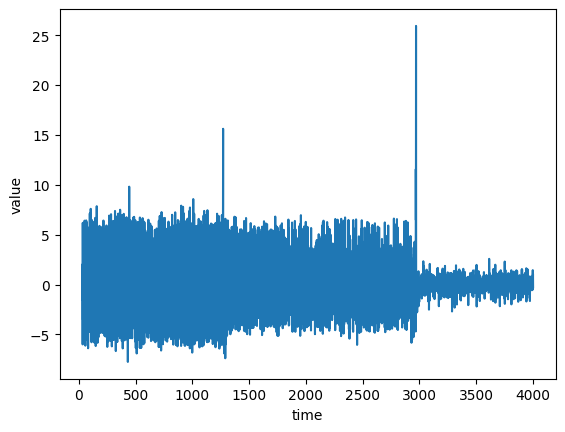

In [77]:
plt.plot(df_noise['value'])
plt.xlabel('time')
plt.ylabel('value')
plt.show()

In [78]:
df_noise


,timestamp,value
0,1392388020,NaN
1,1392388320,NaN
2,1392388620,NaN
3,1392388920,NaN
4,1392389220,NaN
...,...,...
4027,1393596120,NaN
4028,1393596420,NaN
4029,1393596720,NaN
4030,1393597020,NaN


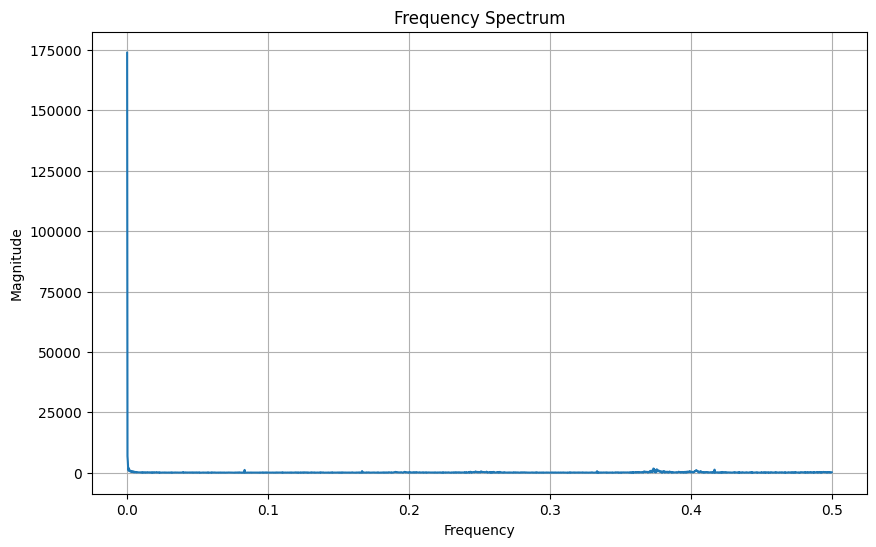

In [79]:
time_series = df['value'].values

# Perform FFT
fft_result = np.fft.fft(time_series)

# Get the frequencies corresponding to the FFT result
fft_freqs = np.fft.fftfreq(len(time_series))
# Compute the magnitude of the FFT result
magnitude = np.abs(fft_result)

# Only keep the positive frequencies (since FFT output is symmetric)
positive_freqs = fft_freqs[np.where(fft_freqs >= 0)]
positive_magnitude = magnitude[np.where(fft_freqs >= 0)]

# Plot the frequency spectrum
plt.figure(figsize=(10, 6))
plt.plot(positive_freqs, positive_magnitude)
plt.title('Frequency Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

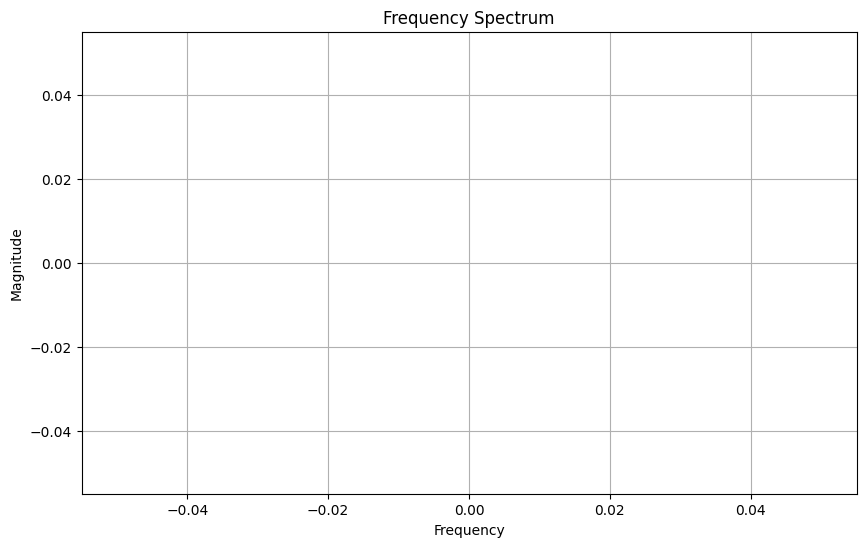

In [80]:
time_series = df_noise['value'].values

# Perform FFT
fft_result = np.fft.fft(time_series)

# Get the frequencies corresponding to the FFT result
fft_freqs = np.fft.fftfreq(len(time_series))
# Compute the magnitude of the FFT result
magnitude = np.abs(fft_result)

# Only keep the positive frequencies (since FFT output is symmetric)
positive_freqs = fft_freqs[np.where(fft_freqs >= 0)]
positive_magnitude = magnitude[np.where(fft_freqs >= 0)]

# Plot the frequency spectrum
plt.figure(figsize=(10, 6))
plt.plot(positive_freqs, positive_magnitude)
plt.title('Frequency Spectrum')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()

In [81]:
def time_segments_aggregate(X, interval, time_column, method=['mean']):
    """Aggregate values over given time span.
    Args:
        X (ndarray or pandas.DataFrame):
            N-dimensional sequence of values.
        interval (int):
            Integer denoting time span to compute aggregation of.
        time_column (int):
            Column of X that contains time values.
        method (str or list):
            Optional. String describing aggregation method or list of strings describing multiple
            aggregation methods. If not given, `mean` is used.
    Returns:
        ndarray, ndarray:
            * Sequence of aggregated values, one column for each aggregation method.
            * Sequence of index values (first index of each aggregated segment).
    """
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X)

    X = X.sort_values(time_column).set_index(time_column)

    if isinstance(method, str):
        method = [method]

    start_ts = X.index.values[0]
    max_ts = X.index.values[-1]

    values = list()
    index = list()
    while start_ts <= max_ts:
        end_ts = start_ts + interval
        subset = X.loc[start_ts:end_ts - 1]
        aggregated = [
            getattr(subset, agg)(skipna=True).values
            for agg in method
        ]
        values.append(np.concatenate(aggregated))
        index.append(start_ts)
        start_ts = end_ts

    return np.asarray(values), np.asarray(index)

X, index = time_segments_aggregate(df_noise, interval=300, time_column='timestamp')

In [82]:
print(X.shape)
print(index.shape)

(4032, 1)
(4032,)


In [83]:
imp = SimpleImputer()
X_1 = imp.fit_transform(X)

scaler = MinMaxScaler(feature_range=(-1, 1))
X_2 = scaler.fit_transform(X_1)
X = scaler.fit_transform(X)

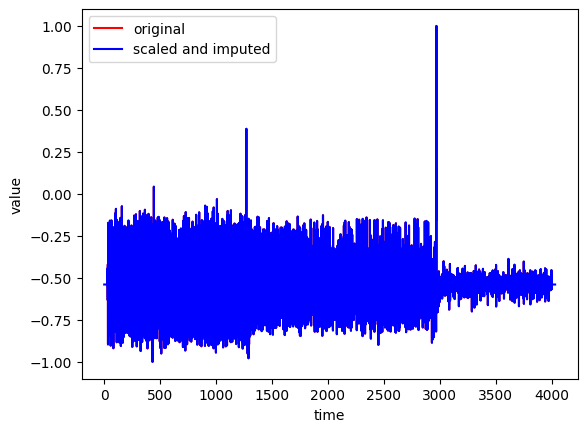

In [84]:
plt.plot(X[:,0],c='r',label='original')
plt.plot(X_2[:,0],c='b',label='scaled and imputed')
plt.legend()
plt.xlabel('time')
plt.ylabel('value')
plt.show()

In [85]:
print(X_2.shape)

(4032, 1)


In [86]:
def rolling_window_sequences(X, index, window_size, target_size, step_size, target_column,
                             drop=None, drop_windows=False):
    """Create rolling window sequences out of time series data.
    The function creates an array of input sequences and an array of target sequences by rolling
    over the input sequence with a specified window.
    Optionally, certain values can be dropped from the sequences.
    Args:
        X (ndarray):
            N-dimensional sequence to iterate over.
        index (ndarray):
            Array containing the index values of X.
        window_size (int):
            Length of the input sequences.
        target_size (int):
            Length of the target sequences.
        step_size (int):
            Indicating the number of steps to move the window forward each round.
        target_column (int):
            Indicating which column of X is the target.
        drop (ndarray or None or str or float or bool):
            Optional. Array of boolean values indicating which values of X are invalid, or value
            indicating which value should be dropped. If not given, `None` is used.
        drop_windows (bool):
            Optional. Indicates whether the dropping functionality should be enabled. If not
            given, `False` is used.
    Returns:
        ndarray, ndarray, ndarray, ndarray:
            * input sequences.
            * target sequences.
            * first index value of each input sequence.
            * first index value of each target sequence.
    """
    out_X = list()
    out_y = list()
    X_index = list()
    y_index = list()
    target = X[:, target_column]

    if drop_windows:
        if hasattr(drop, '__len__') and (not isinstance(drop, str)):
            if len(drop) != len(X):
                raise Exception('Arrays `drop` and `X` must be of the same length.')
        else:
            if isinstance(drop, float) and np.isnan(drop):
                drop = np.isnan(X)
            else:
                drop = X == drop

    start = 0
    max_start = len(X) - window_size - target_size + 1
    while start < max_start:
        end = start + window_size

        if drop_windows:
            drop_window = drop[start:end + target_size]
            to_drop = np.where(drop_window)[0]
            if to_drop.size:
                start += to_drop[-1] + 1
                continue

        out_X.append(X[start:end])
        out_y.append(target[end:end + target_size])
        X_index.append(index[start])
        y_index.append(index[end])
        start = start + step_size

    return np.asarray(out_X), np.asarray(out_y), np.asarray(X_index), np.asarray(y_index)

#Todo: 调参
X, y, X_index, y_index = rolling_window_sequences(X_2, index,
                                                  window_size=110,
                                                  target_size=1,
                                                  step_size=1,
                                                  target_column=0)

In [87]:
print("Training data input shape: {}".format(X.shape))
print("Training data index shape: {}".format(X_index.shape))
print("Training y shape: {}".format(y.shape))
print("Training y index shape: {}".format(y_index.shape))

Training data input shape: (3922, 110, 1)
Training data index shape: (3922,)
Training y shape: (3922, 1)
Training y index shape: (3922,)


In [88]:
def plot_rows(X,window_size):
      idx=np.arange(0,X.shape[1])
      plt.figure(figsize=(6,2))
      plt.plot(idx,X[0,:],color='blue')
      plt.title('window 0')
      plt.show()

      plt.figure(figsize=(6,2))
      plt.plot(idx,X[20,:],color='red')
      plt.title('window 5')
      plt.show()

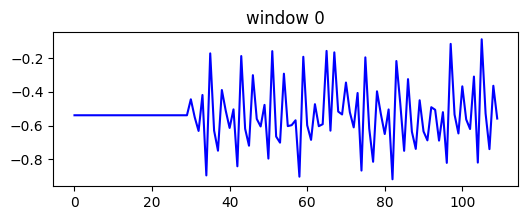

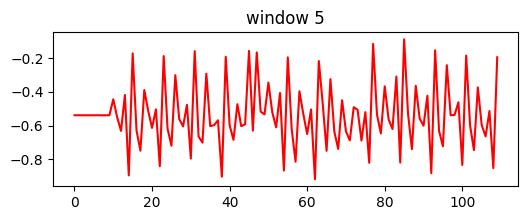

In [89]:
plot_rows(X,100)

In [90]:
import time
from mlstars import load_primitive


#Todo:调参
tadgan = load_primitive('orion.primitives.tadgan.TadGAN',arguments={"X": X, "y":X, "epochs":50, "batch_size": 32,'detailed_losses':True})

start_time = time.time()
tadgan.fit()

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time} seconds")

Epoch: 1/50, Losses: {'cx_loss': array([-1.7383, -4.5557,  1.8222,  0.0995]), 'cz_loss': array([-1.5075,  0.2494, -2.6253,  0.0869]), 'eg_loss': array([ 4.8952, -1.7358,  5.1168,  0.1514])}
Epoch: 2/50, Losses: {'cx_loss': array([-1.711 , -8.1711,  6.3004,  0.016 ]), 'cz_loss': array([-5.6271,  0.9565, -6.9861,  0.0403]), 'eg_loss': array([ 1.9314, -6.2983,  7.6924,  0.0537])}
Epoch: 3/50, Losses: {'cx_loss': array([-1.5351, -5.8677,  4.2244,  0.0108]), 'cz_loss': array([4.9001, 0.7688, 3.1268, 0.1005]), 'eg_loss': array([-6.1386, -4.2363, -2.3365,  0.0434])}
Epoch: 4/50, Losses: {'cx_loss': array([-1.6051, -4.8924,  3.1821,  0.0105]), 'cz_loss': array([-18.2958,   1.0426, -20.6474,   0.1309]), 'eg_loss': array([20.8371, -3.2197, 23.548 ,  0.0509])}
Epoch: 5/50, Losses: {'cx_loss': array([-1.6327, -5.2066,  3.4712,  0.0103]), 'cz_loss': array([ 0.0568,  1.2284, -1.7967,  0.0625]), 'eg_loss': array([-1.3237, -3.5749,  1.922 ,  0.0329])}
Epoch: 6/50, Losses: {'cx_loss': array([-1.6568, -

In [91]:
X_hat, critic = tadgan.produce(X=X,y=X)


123/123 [==============================] - 0s 3ms/step


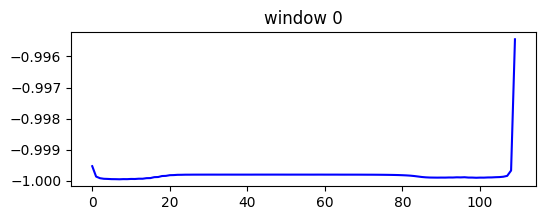

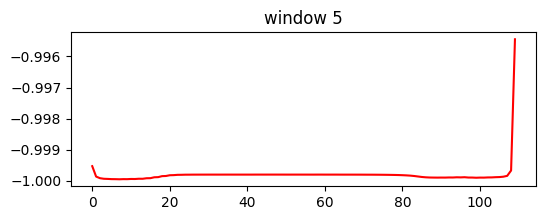

In [92]:
plot_rows(X_hat,100)


In [93]:
def unroll_ts(y_hat):
    predictions = list()
    pred_length = y_hat.shape[1]
    num_errors = y_hat.shape[1] + (y_hat.shape[0] - 1)

    for i in range(num_errors):
            intermediate = []

            for j in range(max(0, i - num_errors + pred_length), min(i + 1, pred_length)):
                intermediate.append(y_hat[i - j, j])

            if intermediate:
                predictions.append(np.median(np.asarray(intermediate)))

    return np.asarray(predictions[pred_length-1:])

In [94]:
def plot_rws(X, window=20, k=5):
    shift = 20
    X = X[window:]
    t = range(len(X))
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


    num_figs = int(np.ceil(k / 5)) + 1
    fig = plt.figure(figsize=(15, num_figs * 2))

    j = 0
    ax = fig.add_subplot(num_figs, 5, j+1)
    idx = t[j: window + j]
    ax.plot(idx, X[j], lw=2, color=colors[j])
    plt.title("window %d" % j, size=16)
    plt.ylim([-1, 1])

    j = 1
    ax = fig.add_subplot(num_figs, 5, j+1)
    idx = t[j: window + j]
    ax.plot(idx, X[j], lw=2, color=colors[j])
    ax.set_yticklabels([])
    plt.title("window %d" % j, size=16)
    plt.ylim([-1, 1])

    for i in range(2, k):
        j = i * shift
        idx = t[j: window + j]

        ax = fig.add_subplot(num_figs, 5, i+1)
        ax.plot(idx, X[j], lw=2, color=colors[i+1])
        ax.set_yticklabels([])
        plt.title("window %d" % j, size=16)
        plt.ylim([-1, 1])

    plt.tight_layout()
    plt.show()

In [95]:
# flatten the predicted windows
y_hat = unroll_ts(X_hat)

print(y_hat.shape)
print(y.shape)

(3922,)
(3922, 1)


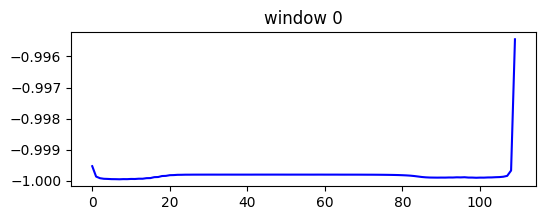

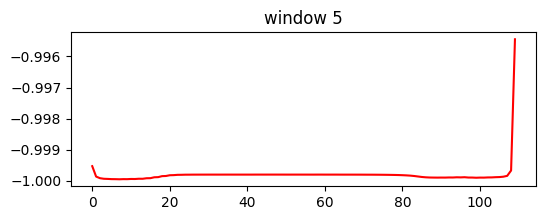

In [96]:
plot_rows(X_hat,100)

In [97]:
def plot_ts(X, labels=None):
    fig = plt.figure(figsize=(30, 6))
    ax = fig.add_subplot(111)

    if not isinstance(X, list):
        X = [X]

    for x in X:
        t = range(len(x))
        plt.plot(t, x)

    plt.title('art data', size=34)
    plt.ylabel('value', size=30)
    plt.xlabel('Time', size=30)
    plt.xticks(size=26)
    plt.yticks(size=26)
    plt.xlim([t[0], t[-1]])

    if labels:
        plt.legend(labels=labels, loc=1, prop={'size': 26})

    plt.show()

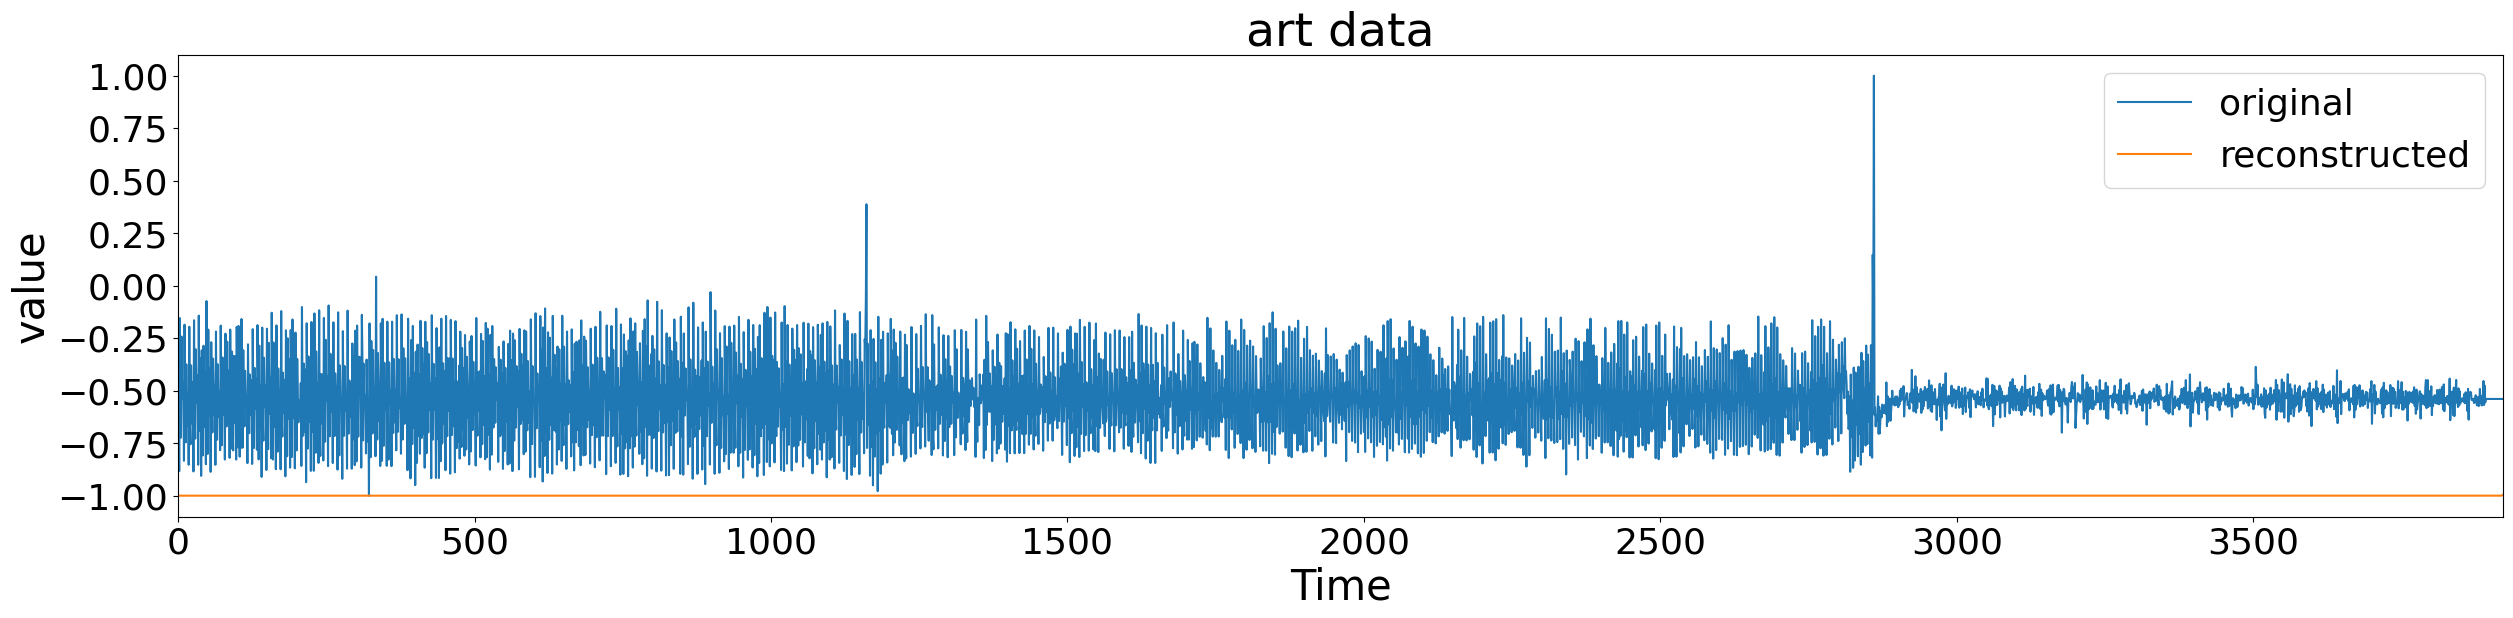

In [98]:
plot_ts([y, y_hat], labels=['original', 'reconstructed'])

In [99]:
print(y.shape)

(3922, 1)


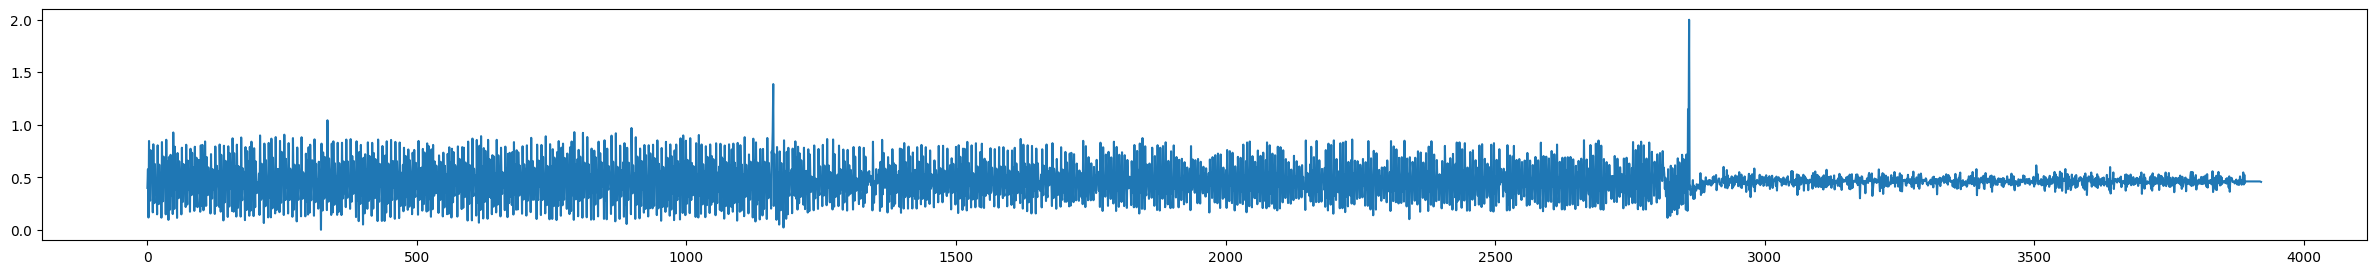

In [100]:
# pair-wise error calculation
error = np.zeros(shape=y.shape)
length = y.shape[0]
for i in range(length):
    error[i] = abs(y_hat[i] - y[i])

# visualize the error curve
fig = plt.figure(figsize=(30, 3))
plt.plot(error)
plt.show()

In [101]:
print(len(df['timestamp']))

4032


In [102]:
from orion.primitives.tadgan import score_anomalies
#Todo: error type
error, true_index, true, pred = score_anomalies(X, X_hat, critic, X_index, rec_error_type="dtw", comb="mult")
pred = np.array(pred).mean(axis=2)


In [103]:
print(len(error))

4031


In [104]:
print(len(df['timestamp']))

4032


In [105]:
import matplotlib.gridspec as gridspec
def plot_error(X):
    plt.figure(figsize = (30, 6))
    gs1 = gridspec.GridSpec(3, 1)
    gs1.update(wspace=0.025, hspace=0.05)

    i = 0
    for x in X:
        if len(x) == 2:
            ax1 = plt.subplot(gs1[i:i+2])
            for line in x:
                t = range(len(line))
                ax1.plot(t, line)
            i+=1
        else:
            ax1 = plt.subplot(gs1[i])
            t = range(len(line))
            ax1.plot(t, x, color='tab:red')

        i+=1
        plt.xlim(t[0], t[-1])
        plt.yticks(size=22)
        plt.axis('on')
        ax1.set_xticklabels([])

    plt.show()

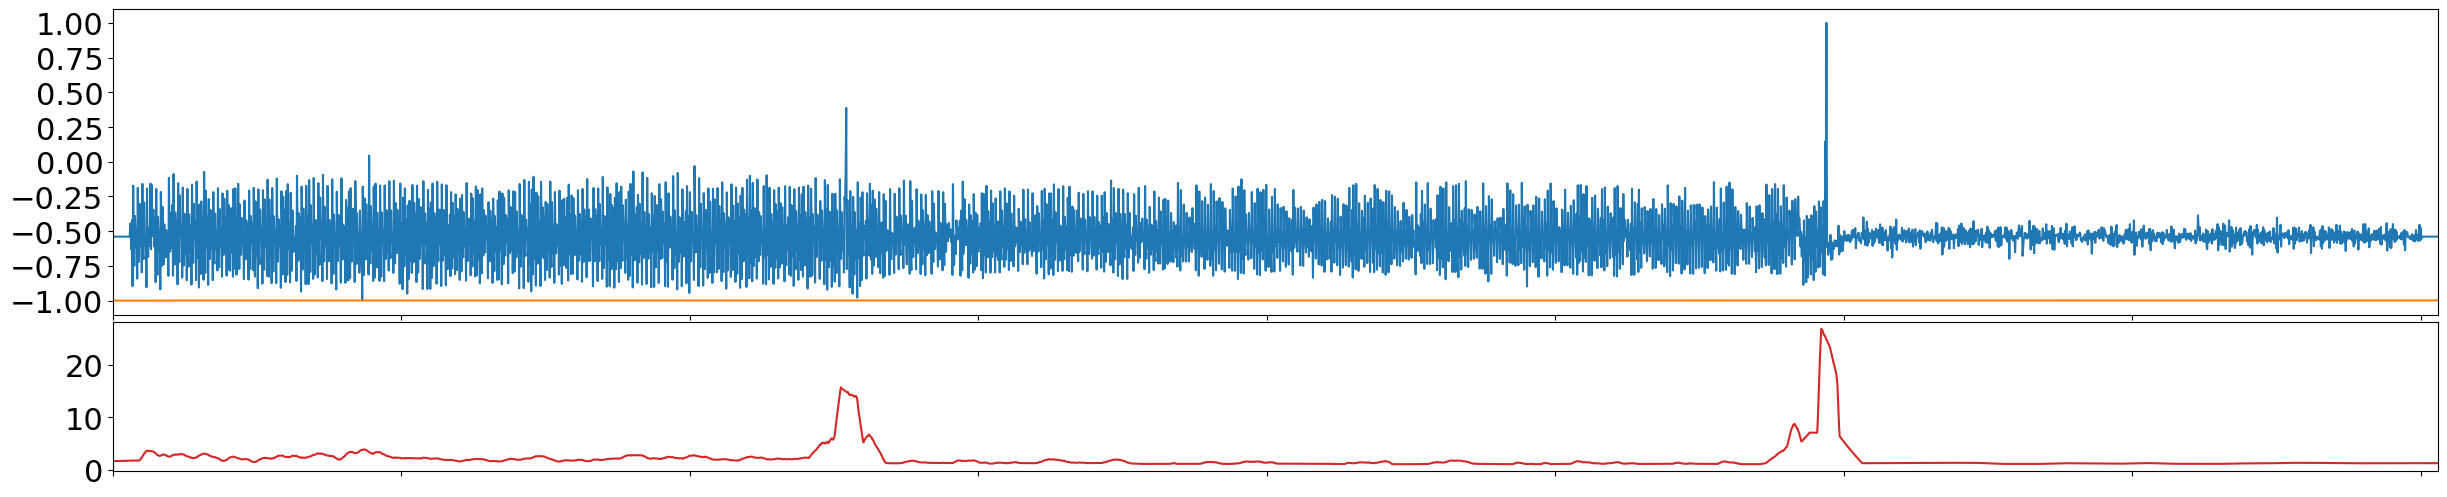

In [106]:
# visualize the error curve
plot_error([[true, pred], error])

In [107]:
print(len(df['timestamp']))

4032


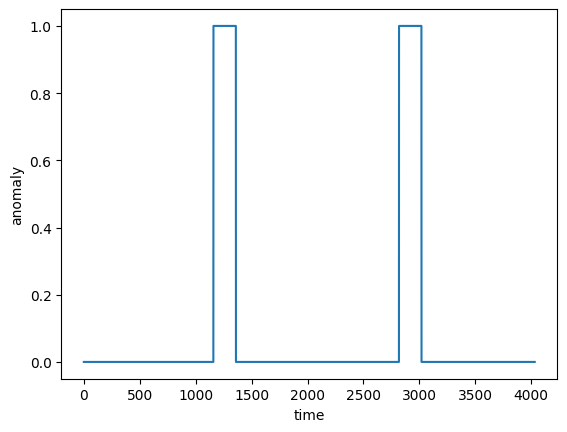

In [108]:
## Run this cell to reproduce the plot correctly
start = known_anomalies['start']
end = known_anomalies['end']
df_new = df.copy()
df_new['label'] = 0

for i in range(len(df_new)):
    for j in range(len(start)):
        if (df_new.loc[i, 'timestamp'] >= start[j] and df_new.loc[i, 'timestamp'] <= end[j]):
            df_new.loc[i, 'label'] = 1
            break

plt.plot(df_new['label'])
plt.xlabel('time')
plt.ylabel('anomaly')
plt.show()

In [109]:
ground_truth=df_new['label']
print(len(df_new['label']))

4032


In [110]:
print(len(ground_truth),len(error))

4032 4031


prob_anomaly:---
 [0.02275901 0.02284656 0.02296173 ... 0.00781999 0.00782568 0.00783193]
shape:  (4031,)


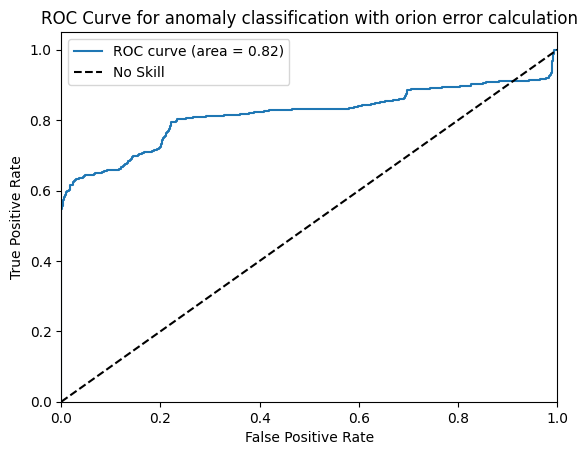

In [111]:
ground_truth_last=ground_truth[:-1]
ground_truth_first=ground_truth[1:]

error_min=np.min(error)
error_max=np.max(error)
error_range=error_max-error_min

prob_anomaly = (error-error_min)/error_range
print('prob_anomaly:---\n',prob_anomaly)
print('shape: ',prob_anomaly.shape)

from sklearn.metrics import roc_curve, auc
# with the last row discarded
fpr, tpr, thresholds = roc_curve(ground_truth_last, prob_anomaly)
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for anomaly classification with orion error calculation')
plt.legend()
plt.show()

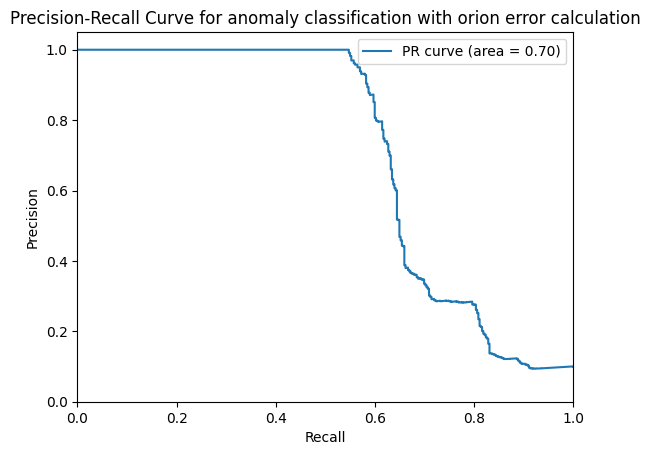

In [112]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, pr_thresholds = precision_recall_curve(ground_truth_last, prob_anomaly)
average_precision = average_precision_score(ground_truth_last, prob_anomaly)

# Plot the PR curve
plt.figure()
plt.plot(recall, precision, label='PR curve (area = %0.2f)' % average_precision)
#plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for anomaly classification with orion error calculation')
plt.legend()
plt.show()

In [113]:
from sklearn.metrics import average_precision_score
avg_precision_score=average_precision_score(ground_truth_last,prob_anomaly)
avg_precision_score

0.704082595225453

In [114]:
sensitivity = np.array(tpr)

# Calculate specificity (true negative rate)
specificity = 1 - np.array(fpr)

# Calculate Youden's J statistic
youden_j = sensitivity + specificity - 1

# Find the index of the maximum Youden's J statistic
best_threshold_index = np.argmax(youden_j)

# Get the corresponding threshold
best_threshold = thresholds[best_threshold_index]

print("Threshold for best performance (Youden's J):", best_threshold)
error_threshold_best=error_range*best_threshold+error_min
print(error_threshold_best)

Threshold for best performance (Youden's J): 0.07405902559709954
2.928181180752459


In [115]:

intervals = list()

i = 0
max_start = len(error)
while i < max_start:
    j = i
    start = index[i]
    while i < len(error) and error[i] > error_threshold_best: #tuning it
        i += 1

    end = index[i]
    if start != end:
        intervals.append((start, end, np.mean(error[j: i+1])))

    i += 1

intervals

[(1392404220, 1392410820, 3.362823665428233),
 (1392422820, 1392423120, 2.9208519222104496),
 (1392423420, 1392424320, 2.92690146778354),
 (1392434520, 1392436620, 2.988339231102702),
 (1392493920, 1392497520, 3.027446187835222),
 (1392509520, 1392528720, 3.330855541025384),
 (1392751620, 1392787620, 8.13774567089227),
 (1393253520, 1393293420, 10.020098863377035)]

In [116]:
from datetime import datetime
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

def convert_date(timelist):
    converted = list()
    for x in timelist:
        converted.append(datetime.fromtimestamp(x))
    return converted

def convert_date_single(x):
    return datetime.fromtimestamp(x)

def plot(dfs, anomalies=[]):
    """ Line plot for time series.

    This function plots time series and highlights anomalous regions.
    The first anomaly in anomalies is considered the ground truth.

    Args:
        dfs (list or `pd.DataFrame`): List of time series in `pd.DataFrame`.
            Or a single dataframe. All dataframes must have the same shape.
        anomalies (list): List of anomalies in tuple format.
    """
    if isinstance(dfs, pd.DataFrame):
        dfs = [dfs]

    if not isinstance(anomalies, list):
        anomalies = [anomalies]

    df = dfs[0]
    time = convert_date(df['timestamp'])
    months = mdates.MonthLocator()  # every month
    days = mdates.DayLocator() # every day

    month_fmt = mdates.DateFormatter('%b')

    fig = plt.figure(figsize=(30, 6))
    ax = fig.add_subplot(111)

    for df in dfs:
        plt.plot(time, df['value'])

    colors = ['red'] + ['green'] * (len(anomalies) - 1)
    for i, anomaly in enumerate(anomalies):
        if not isinstance(anomaly, list):
            anomaly = list(anomaly[['start', 'end']].itertuples(index=False))

        for _, anom in enumerate(anomaly):
            t1 = convert_date_single(anom[0])
            t2 = convert_date_single(anom[1])
            plt.axvspan(t1, t2, color=colors[i], alpha=0.2)

    plt.title('art_jumpsdown data', size=34)
    plt.ylabel('value', size=30)
    plt.xlabel('Time', size=30)
    plt.xticks(size=26)
    plt.yticks(size=26)
    plt.xlim([time[0], time[-1]])

    # format xticks
    ax.xaxis.set_major_locator(months)
    ax.xaxis.set_major_formatter(month_fmt)
    ax.xaxis.set_minor_locator(days)

    # format yticks
    ylabels = ['{:,.0f}'.format(x) + 'K' for x in ax.get_yticks()/1000]
    ax.set_yticklabels(ylabels)

    plt.show()

In [117]:
anomalies = pd.DataFrame(intervals, columns=['start', 'end', 'score'])


In [118]:
def plot_func_with_anomaly(data,anomalies,test=False,predicted_anomalies=None):
    plt.figure(figsize=(40, 6))

    # Plot the time series data
    plt.plot(data['timestamp'], data['value'], label='Time Series Data',linewidth=2.5)

    # Shade the anomalous parts

    for i, row in anomalies.iterrows():
        plt.axvspan(row['start'], row['end'], color='green', alpha=0.3, label='Anomalous Part')

    if(test==True):
        for i, row in predicted_anomalies.iterrows():
            plt.axvspan(row['start'], row['end'], color='red', alpha=0.3, label='predicted Anomalous Part')

    # Add legend and labels

    plt.xlabel('Timestamp')
    plt.ylabel('Value')
    plt.title('Time Series Plot with Anomalous Parts')

    # Show plot
    plt.show()

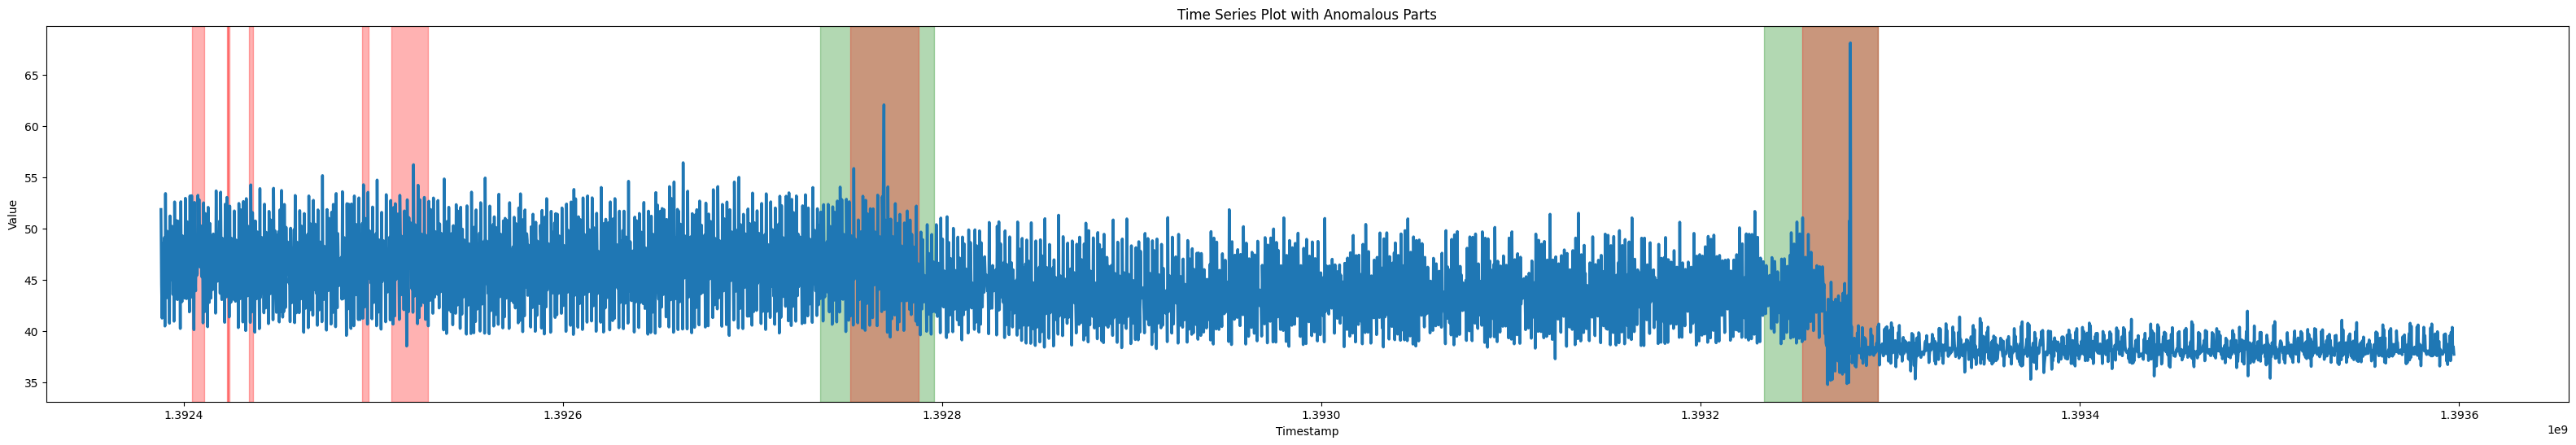

In [119]:

plot_func_with_anomaly(df,known_anomalies,test=True,predicted_anomalies=anomalies)

In [120]:
from orion.evaluation.contextual import contextual_accuracy, contextual_f1_score



accuracy = contextual_accuracy(known_anomalies, anomalies, start=start, end=end)
f1_score = contextual_f1_score(known_anomalies, anomalies, start=start, end=end)

print("Accuracy score = {:0.3f}".format(accuracy))
print("F1 score = {:0.3f}".format(f1_score))

from orion.evaluation.contextual import contextual_confusion_matrix

confusion_matrix = contextual_confusion_matrix(known_anomalies, anomalies, start=start, end=end)

tn=confusion_matrix[0]
fp=confusion_matrix[1]
fn=confusion_matrix[2]
tp=confusion_matrix[3]

precision=tp/(tp+fp)
recall=tp/(tp+fn)
print("precision: ",precision)
print("recall: ",recall)

Accuracy score = 0.936
F1 score = 0.664
precision:  0.6988619622863878
recall:  0.6325061248979184
